# *Data Cleaning*

In [40]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [41]:
df=pd.read_csv('dataset.csv')
df.head()

,text_type,text
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,4 color printing special request additional in...
4,spam,do not have money get software cds from here s...


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20348 entries, 0 to 20347
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text_type  20348 non-null  object
 1   text       20348 non-null  object
dtypes: object(2)
memory usage: 318.1+ KB


# *Handle Missing & Duplicated Values*

In [43]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({
'Missing Count' : missing,
'Missing %'     : missing_pct
}).query('`Missing Count` > 0')

print("Missing Values:")
print(quality_report.to_string())
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
Duplicate rows: 14


In [44]:
# remove Duplicate rows
df.drop_duplicates(inplace=True)
print(f"Duplicate rows after removal: {df.duplicated().sum()}")

Duplicate rows after removal: 0


# *Text Cleaning*

In [45]:
Words_dict = {
    'u': 'you',
    'ur': 'your',
    'r': 'are',
    '4u': 'for you',
    'gr8': 'great',
    'b4': 'before',
    'plz': 'please',
    'msg': 'message',
    'txt': 'text',
}

def replace_words(text):
    text = text.lower()
    words = text.split()
    new_words = [Words_dict.get(word, word) for word in words]
    return " ".join(new_words)
  
df['text'] = df['text'].apply(replace_words)

In [ ]:
def clean_text(text):
    text = str(text).lower()
    
    text = re.sub(r'(http|https):\/\/[\w\-]+(\.[\w\-]+)+([\w\-\.,@?^=%&:/~\+#]*[\w\-\@?^=%&/~\+#])?', ' <url> ', text)
    
    text = re.sub(r'£|\$|€', ' <cur> ', text)
    text = re.sub(r'\b\d+\b', ' <num> ', text)
    
    text = re.sub(r'[^a-z\s<>]', ' ', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df['text'] = df['text'].apply(clean_text)
df.head()

,text_type,text
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,<num> color printing special request additiona...
4,spam,do not have money get software cds from here s...


<Axes: xlabel='text_type'>

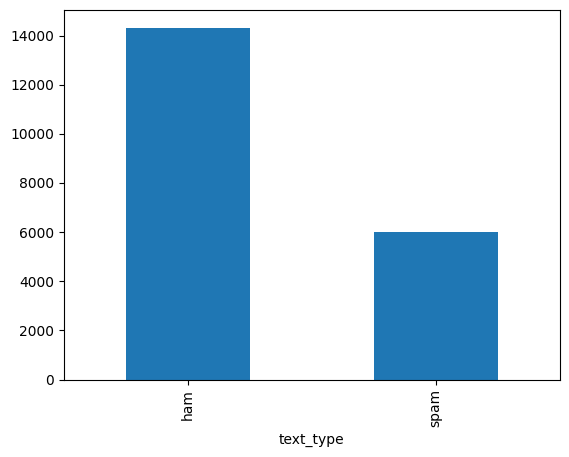

In [47]:
df['text_type'].value_counts().plot(kind='bar')


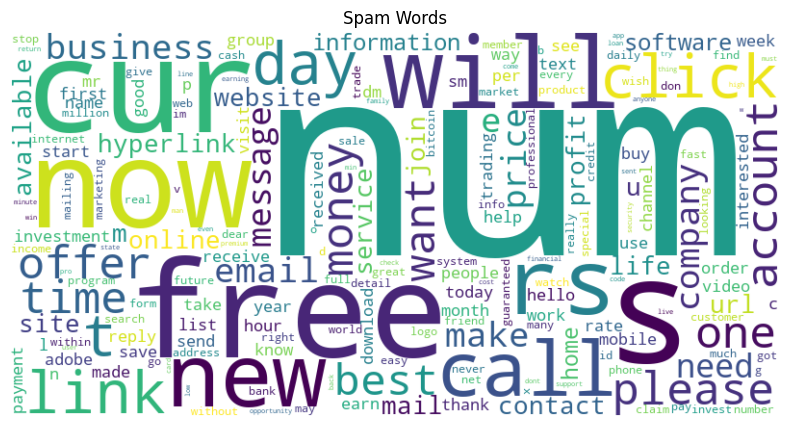

In [48]:
spam_text = " ".join(df[df['text_type'] == 'spam']['text'])

wordcloud_spam = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title("Spam Words")
plt.axis("off")
plt.show()

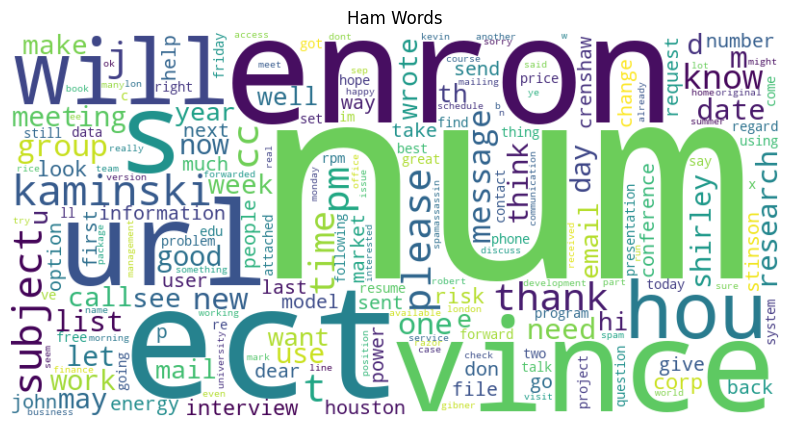

In [49]:
ham_text = " ".join(df[df['text_type'] == 'ham']['text'])

wordcloud_ham = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title("Ham Words")
plt.axis("off")
plt.show()